# Actividad 2: Clustering no supervisado

- Alex Rubiño Fernández
- Aprendizaje Automático 2
- 11/05/2026
- UNIR

## Índice

1. [Ejercicio 1: Generación y visualización del dataset](#ejercicio-1-generación-y-visualización-del-dataset)
2. [Ejercicio 2: SVM con kernel lineal y ajuste de hiperparámetros](#ejercicio-2-svm-con-kernel-lineal-y-ajuste-de-hiperparámetros)
3. [Ejercicio 3: SVM con kernels no lineales y ajuste de hiperparámetros](#ejercicio-3-svm-con-kernels-no-lineales-y-ajuste-de-hiperparámetros)
4. [Ejercicio 4: Visualización de fronteras de decisión y comparativa de rendimiento](#ejercicio-4-visualización-de-fronteras-de-decisión-y-comparativa-de-rendimiento)
5. [Ejercicio 5: Discusión y comparación de resultados](#ejercicio-5-discusión-y-comparación-de-resultados)

## Ejercicio 1: Generación y visualización del dataset

Generamos un dataset sintético con las siguientes características: dos círculos concéntricos con grosor aleatorio, tres círculos adicionales también con grosor aleatorio (algunos de ellos se cortan entre sí y con los círculos concéntricos), y seis bloques compactos distribuidos entre los círculos anteriores. Por último, visualizamos el dataset resultante.

Para ello, creamos una función generar_circulo que genera puntos alrededor de un círculo con ruido gaussiano para simular el grosor. Generamos dos círculos concéntricos centrados en (0,0) con radios 1.0 y 1.8 respectivamente, ambos con 400 puntos y un grosor de 0.08. A continuación, generamos tres círculos adicionales: el círculo 3 centrado en (2.2, 1.2) con radio 0.9, el círculo 4 en (1.8, -1.5) con radio 0.8, y el círculo 5 en (-2.0, 1.3) con radio 0.8, todos ellos con grosor 0.07 y 300 puntos cada uno. Para los seis bloques compactos, utilizamos make_blobs generando 60 muestras alrededor de cada centro, con una desviación estándar de 0.08. Los centros de los bloques son: (0.6, 1.3), (-0.7, 1.4), (1.3, -0.6), (-1.2, -0.7), (1.4, 0.7) y (-1.4, 0.9). Finalmente, combinamos todos los puntos en un único dataset sin etiquetas (aprendizaje no supervisado) y mostramos los datos en un gráfico de dispersión.

Círculo interior (radio 1.2): 600 puntos
Círculo exterior (radio 2.5): 800 puntos

Círculo adicional 1 (centro 0.5,0.3 radio 0.5): 400 puntos
Círculo adicional 2 (centro -0.4,0.6 radio 0.45): 400 puntos
Círculo adicional 3 (centro 0.1,-0.7 radio 0.5): 400 puntos
Bloque 1: 60 puntos en (0.6, 1.3)
Bloque 2: 60 puntos en (-0.7, 1.4)
Bloque 3: 60 puntos en (1.3, -0.6)
Bloque 4: 60 puntos en (-1.2, -0.7)
Bloque 5: 60 puntos en (1.4, 0.7)
Bloque 6: 60 puntos en (-1.4, 0.9)

Total puntos en bloques compactos: 360
Dataset final: 2960 muestras, 2 características
NOTA: No se incluyen etiquetas (aprendizaje no supervisado)


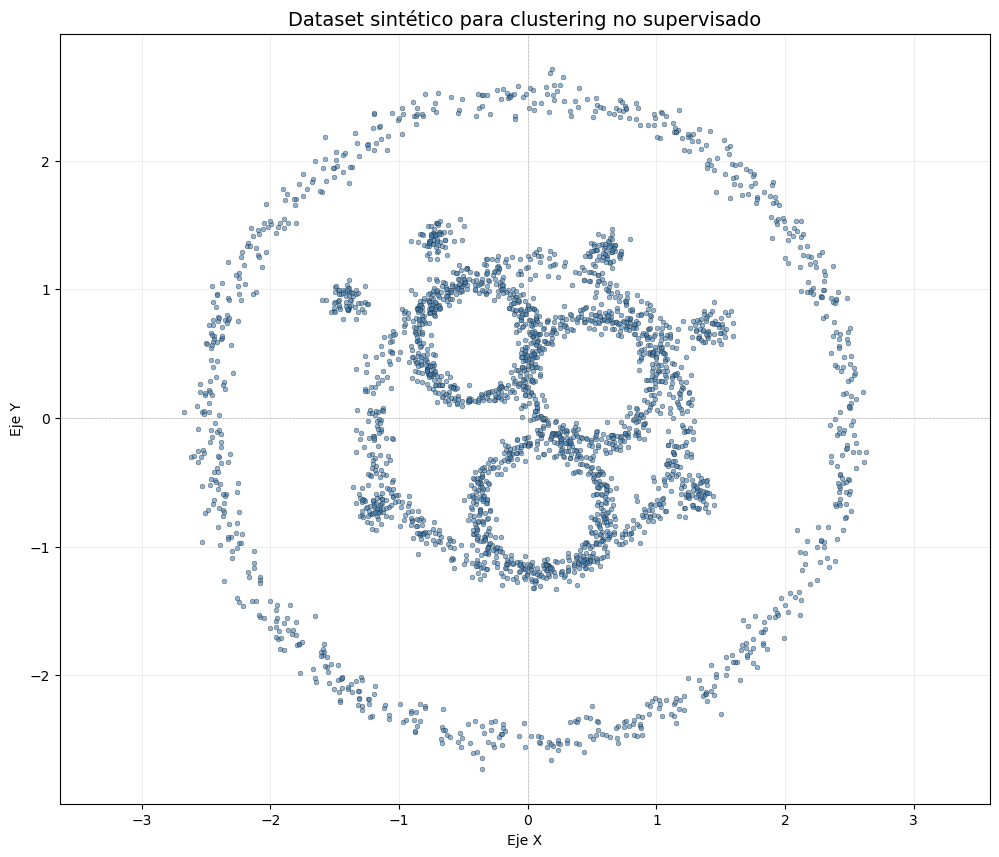

In [11]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Fijamos semilla para reproducibilidad
np.random.seed(42)

def generar_circulo(centro_x, centro_y, radio, n_puntos, grosor):
    """
    Genera puntos alrededor de un círculo con grosor (ruido gaussiano)
    """
    angulos = np.random.uniform(0, 2*np.pi, n_puntos)
    r = radio + np.random.normal(0, grosor, n_puntos)
    x = centro_x + r * np.cos(angulos)
    y = centro_y + r * np.sin(angulos)
    return np.column_stack([x, y])

# Dos círculos concéntricos en (0,0)
circulo_int = generar_circulo(0, 0, 1.2, 600, 0.06)   # círculo interior
circulo_ext = generar_circulo(0, 0, 2.5, 800, 0.08)   # círculo exterior

print(f"Círculo interior (radio 1.2): {circulo_int.shape[0]} puntos")
print(f"Círculo exterior (radio 2.5): {circulo_ext.shape[0]} puntos")

# Círculo 1: centrado en (0.5, 0.3) con radio 0.5
circulo_adicional1 = generar_circulo(0.5, 0.3, 0.5, 400, 0.05)

# Círculo 2: centrado en (-0.4, 0.6) con radio 0.45
circulo_adicional2 = generar_circulo(-0.4, 0.6, 0.45, 400, 0.05)

# Círculo 3: centrado en (0.1, -0.7) con radio 0.5 (se corta con los anteriores)
circulo_adicional3 = generar_circulo(0.1, -0.7, 0.5, 400, 0.05)

print(f"\nCírculo adicional 1 (centro 0.5,0.3 radio 0.5): {circulo_adicional1.shape[0]} puntos")
print(f"Círculo adicional 2 (centro -0.4,0.6 radio 0.45): {circulo_adicional2.shape[0]} puntos")
print(f"Círculo adicional 3 (centro 0.1,-0.7 radio 0.5): {circulo_adicional3.shape[0]} puntos")

# Posiciones de los 6 bloques compactos
centros_blobs = [
    (0.6, 1.3), (-0.7, 1.4), (1.3, -0.6),
    (-1.2, -0.7), (1.4, 0.7), (-1.4, 0.9)
]

bloques = []
for i, centro in enumerate(centros_blobs):
    blob, _ = make_blobs(n_samples=60, centers=[centro], cluster_std=0.08, n_features=2)
    bloques.append(blob)
    print(f"Bloque {i+1}: {blob.shape[0]} puntos en {centro}")

# Unir todos los bloques en un solo array
bloques_compactos = np.vstack(bloques)
print(f"\nTotal puntos en bloques compactos: {bloques_compactos.shape[0]}")
# Unir todos los componentes
X = np.vstack([circulo_int, circulo_ext, circulo_adicional1, circulo_adicional2, circulo_adicional3, bloques_compactos])

print(f"Dataset final: {X.shape[0]} muestras, {X.shape[1]} características")
print("NOTA: No se incluyen etiquetas (aprendizaje no supervisado)")

plt.figure(figsize=(12, 10))

plt.scatter(X[:, 0], X[:, 1], s=12, alpha=0.6, c='steelblue', edgecolors='k', linewidth=0.3)

plt.title('Dataset sintético para clustering no supervisado', fontsize=14)
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axis('equal')
plt.grid(alpha=0.2)
plt.show()

Círculo interior - grosor: 0.0462
Círculo exterior - grosor: 0.0691
Círculo adicional 1 - grosor: 0.0965
Círculo adicional 2 - grosor: 0.1055
Círculo adicional 3 - grosor: 0.0803
Bloque 1: 80 puntos en (0.8, 1.0)
Bloque 2: 80 puntos en (-0.9, 0.9)
Bloque 3: 80 puntos en (1.2, -0.5)
Bloque 4: 80 puntos en (-1.1, -0.8)
Bloque 5: 80 puntos en (0.6, -0.2)
Bloque 6: 80 puntos en (-0.5, -0.3)

Total puntos en bloques: 480

Dataset final: 3080 muestras, 2 características
NOTA: Dataset sin etiquetas (aprendizaje no supervisado)


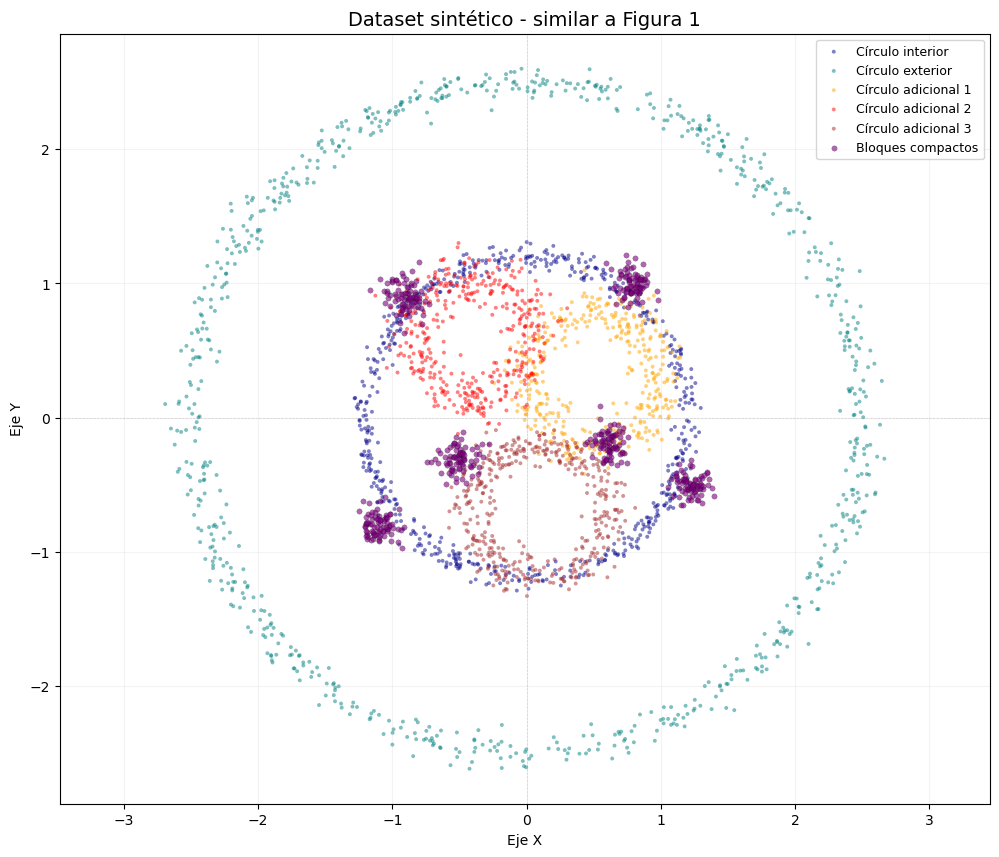

In [13]:
def generar_circulo(centro_x, centro_y, radio, n_puntos, grosor_min=0.04, grosor_max=0.12):
    """
    Genera puntos alrededor de un círculo con grosor ALEATORIO.
    El grosor se elige aleatoriamente entre grosor_min y grosor_max.
    """
    # Grosor aleatorio para este círculo
    grosor = np.random.uniform(grosor_min, grosor_max)
    
    angulos = np.random.uniform(0, 2*np.pi, n_puntos)
    r = radio + np.random.normal(0, grosor, n_puntos)
    x = centro_x + r * np.cos(angulos)
    y = centro_y + r * np.sin(angulos)
    return np.column_stack([x, y]), grosor

# Dos círculos concéntricos en (0,0) con grosor aleatorio
circulo_int, g1 = generar_circulo(0, 0, 1.2, 600)
circulo_ext, g2 = generar_circulo(0, 0, 2.5, 800)

print(f"Círculo interior - grosor: {g1:.4f}")
print(f"Círculo exterior - grosor: {g2:.4f}")

# Tres círculos adicionales DENTRO del círculo interior con grosor aleatorio
circulo_adicional1, g3 = generar_circulo(0.5, 0.3, 0.5, 400)
circulo_adicional2, g4 = generar_circulo(-0.4, 0.6, 0.45, 400)
circulo_adicional3, g5 = generar_circulo(0.1, -0.7, 0.5, 400)

print(f"Círculo adicional 1 - grosor: {g3:.4f}")
print(f"Círculo adicional 2 - grosor: {g4:.4f}")
print(f"Círculo adicional 3 - grosor: {g5:.4f}")

centros_bloques = [
    (0.8, 1.0),      # bloque fuera, zona superior derecha
    (-0.9, 0.9),     # bloque fuera, zona superior izquierda
    (1.2, -0.5),     # bloque fuera, zona derecha
    (-1.1, -0.8),    # bloque fuera, zona izquierda
    (0.6, -0.2),     # bloque dentro, entre círculos adicionales
    (-0.5, -0.3)     # bloque dentro, entre círculos adicionales
]

bloques = []
for i, centro in enumerate(centros_bloques):
    blob, _ = make_blobs(n_samples=80, centers=[centro], cluster_std=0.08, n_features=2)
    bloques.append(blob)
    print(f"Bloque {i+1}: {blob.shape[0]} puntos en {centro}")

bloques_compactos = np.vstack(bloques)
print(f"\nTotal puntos en bloques: {bloques_compactos.shape[0]}")

# ===========================================
# Unir todo en un solo dataset
# ===========================================
X = np.vstack([circulo_int, circulo_ext, circulo_adicional1, circulo_adicional2, circulo_adicional3, bloques_compactos])

print(f"\nDataset final: {X.shape[0]} muestras, {X.shape[1]} características")
print("NOTA: Dataset sin etiquetas (aprendizaje no supervisado)")

# Visualización del dataset (con colores para distinguir estructuras)
plt.figure(figsize=(12, 10))

plt.scatter(circulo_int[:, 0], circulo_int[:, 1], s=8, alpha=0.5, c='darkblue', edgecolors='none', label='Círculo interior')
plt.scatter(circulo_ext[:, 0], circulo_ext[:, 1], s=8, alpha=0.5, c='teal', edgecolors='none', label='Círculo exterior')
plt.scatter(circulo_adicional1[:, 0], circulo_adicional1[:, 1], s=8, alpha=0.5, c='orange', edgecolors='none', label='Círculo adicional 1')
plt.scatter(circulo_adicional2[:, 0], circulo_adicional2[:, 1], s=8, alpha=0.5, c='red', edgecolors='none', label='Círculo adicional 2')
plt.scatter(circulo_adicional3[:, 0], circulo_adicional3[:, 1], s=8, alpha=0.5, c='brown', edgecolors='none', label='Círculo adicional 3')
plt.scatter(bloques_compactos[:, 0], bloques_compactos[:, 1], s=15, alpha=0.6, c='purple', edgecolors='k', linewidth=0.2, label='Bloques compactos')

plt.title('Dataset sintético - similar a Figura 1', fontsize=14)
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.legend(loc='upper right', fontsize=9)
plt.axis('equal')
plt.grid(alpha=0.15)
plt.show()